New Figures for *Neurocomputing* Paper. This file mainly provides code for Figure generation, with some explanation in the objectives and theory. Most of the theory is given in `basics.ipynb`.

# Imports

In [2]:
# Imports
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.gridspec import GridSpec
from matplotlib.colors import LinearSegmentedColormap
import gymnasium as gym
import multiprocess as mp
import pickle
import torch
from copy import deepcopy
from time import perf_counter
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from coin import COIN
from environments import CustomMountainCarEnv
from rl import QLearningAgent, COINQLearningAgent

%matplotlib inline
%load_ext autoreload
%autoreload 2

# Figure 7: Training Performance

Displays the performance of the model as it is trained. We choose here to use a simple Mountain Car with Q-Learning, since it is our simplest algorithm, with stability guarantees. We vary the *gravitational strength* of the path as a parameter, and then do direct sequential training with a few different models:
1. *Default, Zero-shot Single Policy*: Traditional Q-learning. No knowledge of contextual parameter.
2. *N-policy oracle setup*: Contextual Q-learning, where learning is divided between $N$ different policies, each activating for a different regime of simulation parameter (*oracle* comes from the fact that this parameter and the underlying regime assignment is known by the agent).
3. *COIN approach*: Our initial model. Assumes COIN directly infers context probabilities through measurements of the contextual parameter (in this case given), and then builds new policies at real-time through training whenever new contexts are instantiated.
4. *Embodied COIN approach*: COIN is implemented with a slow learning body that is **pre-trained**, i.e. a body that is already adapted to the environment. This is our main targetted approach. We also show a line for a *headless* behaviour, what happens if the contexts are cut-off and the model only uses the body information.

In [4]:
param = np.concatenate([
    0.0*np.ones((5000, )), 
    1.0*np.ones((5000, )),
    1.5*np.ones((5000, )),
    0.5*np.ones((5000, )),
    0.5*np.ones((5000, )),
    1.5*np.ones((5000, )),
    0.0*np.ones((5000, )),
    1.0*np.ones((5000, )),
    1.0*np.ones((500, ))
    ])

N_REPS = 100 # Number of repetitions of each model for averaging
MAX_CORES = mp.cpu_count() - 1 # Number of parallel processes to use
TRAIN = False # Set to True to train, False to load saved results

## Parameter Variation

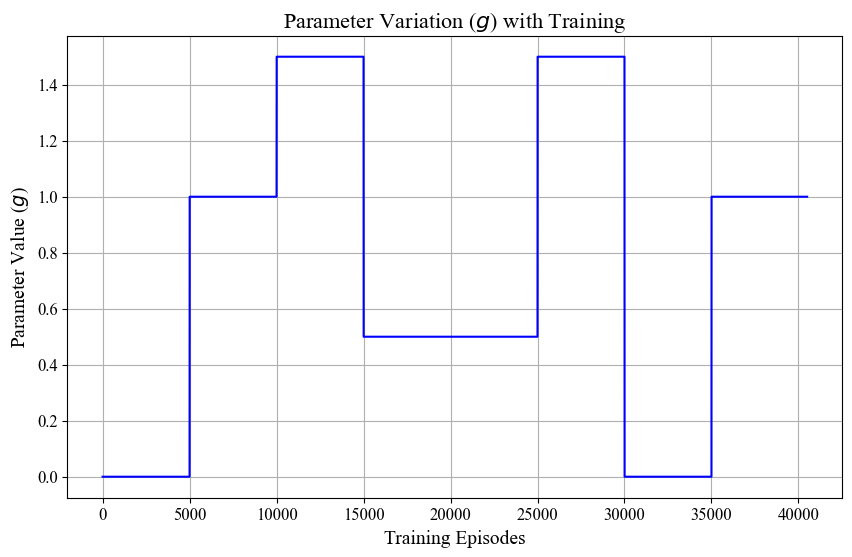

In [5]:
# Plot parameter variation
# Font setup
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "legend.fontsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# Create figure and axiss
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(param, color='blue')
ax.set_title(r'Parameter Variation ($g$) with Training')
ax.set_xlabel('Training Episodes')
ax.set_ylabel(r'Parameter Value ($g$)')
ax.grid(True)
plt.show()


## Zero-shot one policy model

In [8]:
def run_single_zero_shot_F7(rep_id, g):
    """
    Runs one repetition of training with a simple Q-learning agent on the CustomMountainCarEnv, with gravitational variation
    per episode as defined by g.
    Returns the list of rewards obtained for each episode.
    """
    # Imports for multiprocessing
    from environments import CustomMountainCarEnv
    from rl import QLearningAgent

    # Create a fresh agent and environment inside each process
    env = CustomMountainCarEnv(gravity_sf=g[0], render_mode="none")
    agent = QLearningAgent(
        env=env,
        num_position_bins=30,
        num_velocity_bins=30,
        alpha=0.1,
        gamma=0.99,
        epsilon=1.0,
        epsilon_decay=0.999,
        min_epsilon=0.01
    )

    rewards_for_this_rep = []
    for i, gravity in enumerate(g):
        # Create the environment for each gravity
        env = CustomMountainCarEnv(gravity_sf=gravity, render_mode="none")
        
        # Train the agent in the current context
        training_reward = agent.train_step(env=env, max_steps_per_episode=200)
        rewards_for_this_rep.append(training_reward)

        # Reset the environment epsilon at a change in gravity
        if i > 0 and gravity != g[i - 1]:
            agent.epsilon = 1.0

        if (i + 1) % 500 == 0:
            print(f"Repetition {rep_id}, Gravity {gravity}: Training reward = {training_reward}")
    return rewards_for_this_rep

REWARDS_PATH = "models/fig7_zeroshot.npy"
if TRAIN:
    # Number of repetitions and number of parallel processes:
    n_reps = N_REPS
    n_processes = MAX_CORES
        
    # Create a Pool of workers
    with mp.Pool(processes=n_processes) as pool:
        # Map each repetition to the function run_single_zero_shot_F7
        all_results = pool.starmap(run_single_zero_shot_F7, [(rep, param) for rep in range(n_reps)])
        
    # all_results is a list of lists: one list of rewards for each repetition
    # Convert to a NumPy array, then average over axis=0 to get mean reward per amplitude
    all_results_array = np.array(all_results)  # shape: (n_reps, len(sf))
    rewards_F7_zeroshot = np.mean(all_results_array, axis=0)

    # Also get error bars (std dev) for plotting
    rewards_F7_zeroshot_std = np.std(all_results_array, axis=0)

    # Concatenate into a single array for saving
    rewards_F7_zeroshot = np.vstack((rewards_F7_zeroshot, rewards_F7_zeroshot_std))

    # Save results
    np.save(REWARDS_PATH, rewards_F7_zeroshot)
    print(f"Training complete. Rewards saved to '{REWARDS_PATH}'.")
else:
    # Load the saved results from the training
    if os.path.exists(REWARDS_PATH):
        rewards_F7_zeroshot = np.load(REWARDS_PATH)
        print(f"Loaded rewards from '{REWARDS_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved rewards found at '{REWARDS_PATH}'.")

Loaded rewards from 'models/fig7_zeroshot.npy'.


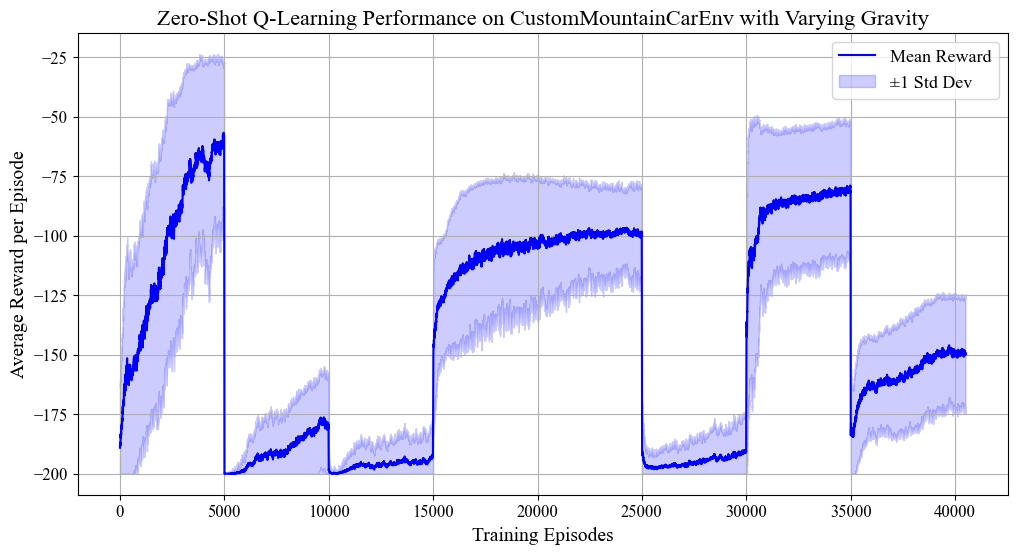

In [9]:
# Plot training results and confidence region
# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 6))
# Extract mean rewards and std dev - smooth for plotting
mean_rewards = np.convolve(rewards_F7_zeroshot[0], np.ones(10)/10, mode='valid')
std_rewards = np.convolve(rewards_F7_zeroshot[1], np.ones(10)/10, mode='valid')
# Plot mean rewards
ax.plot(mean_rewards, label='Mean Reward', color='blue')
# Plot confidence region
ax.fill_between(
    range(len(mean_rewards)),
    np.clip(mean_rewards - std_rewards, a_min=-200, a_max=None),
    mean_rewards + std_rewards,
    color='blue',
    alpha=0.2,
    label='±1 Std Dev'
) 
ax.set_title('Zero-Shot Q-Learning Performance on CustomMountainCarEnv with Varying Gravity')
ax.set_xlabel('Training Episodes')
ax.set_ylabel('Average Reward per Episode')
ax.legend()
ax.grid(True)
plt.show()


## Oracle N-Policy Model

In [10]:
# Set up p_context
p_contexts = np.zeros((len(param), 5))
p_contexts[param == 0.0, 0] = 1.0
p_contexts[param == 0.5, 1] = 1.0
p_contexts[param == 1.0, 2] = 1.0
p_contexts[param == 1.5, 3] = 1.0

# Set up oracle_context, a variable length (N=len(param)), indicating the active context for each time point (index of p_context that is 1)
oracle_context = np.zeros(len(param), dtype=int)
oracle_context[param == 0.0] = 0
oracle_context[param == 0.5] = 1
oracle_context[param == 1.0] = 2
oracle_context[param == 1.5] = 3

def run_single_rep_oracle_F7(rep_id, g, p_context):
    """
    Runs one repetition of training across all gravitational values in g using COINQLearningAgent with oracle context (gravity).
    Returns the list of rewards.
    """
    # Imports for multiprocessing
    from environments import CustomMountainCarEnv
    from rl import COINQLearningAgent
    # Create a fresh agent and environment inside each process

    C = p_context.shape[1]-1

    env = CustomMountainCarEnv(amplitude=1.0, render_mode="none")
    agent = COINQLearningAgent(
        env=env,
        max_contexts=C,
        num_position_bins=30,
        num_velocity_bins=30,
        alpha=0.1,
        gamma=0.99,
        epsilon=1.0,
        epsilon_decay=0.999
    )

    rewards_for_this_rep = []
    for i, val in enumerate(g):
        # Create the environment for each amplitude
        env = CustomMountainCarEnv(gravity_sf=val, render_mode="none")
        
        # Train the agent in the current context
        training_reward = agent.train_step(env=env, p_context=p_context[i,:], max_steps_per_episode=200)
        rewards_for_this_rep.append(training_reward)

        if (i + 1) % 500 == 0:
            print(f"Repetition {rep_id}, Gravity {val}: Training reward = {training_reward}")

    return rewards_for_this_rep

REWARDS_PATH = "models/fig7_rewards_oracle.npy"
if TRAIN:
    # Number of repetitions and number of parallel processes:
    n_reps = N_REPS
    n_processes = MAX_CORES
        
    # Create a Pool of workers
    with mp.Pool(processes=n_processes) as pool:
        # Map each repetition to the function run_single_rep_oracle_F7
        all_results = pool.starmap(run_single_rep_oracle_F7, [(rep, param, p_contexts) for rep in range(n_reps)])
        
    # all_results is a list of lists: one list of rewards for each repetition
    # Convert to a NumPy array, then average over axis=0 to get mean reward per amplitude
    all_results_array = np.array(all_results)  # shape: (n_reps, len(sf))
    rewards_F7_oracle = np.mean(all_results_array, axis=0)
    # Also get error bars (std dev) for plotting
    rewards_F7_oracle_std = np.std(all_results_array, axis=0)

    # Concatenate into a single array for saving
    rewards_F7_oracle = np.vstack((rewards_F7_oracle, rewards_F7_oracle_std))

    # Save results
    np.save(REWARDS_PATH, rewards_F7_oracle)
    print(f"Training complete. Rewards saved to '{REWARDS_PATH}'.")
else:
    # Load the saved results from the training
    if os.path.exists(REWARDS_PATH):
        rewards_F7_oracle = np.load(REWARDS_PATH)
        print(f"Loaded rewards from '{REWARDS_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved rewards found at '{REWARDS_PATH}'.")

Loaded rewards from 'models/fig7_rewards_oracle.npy'.


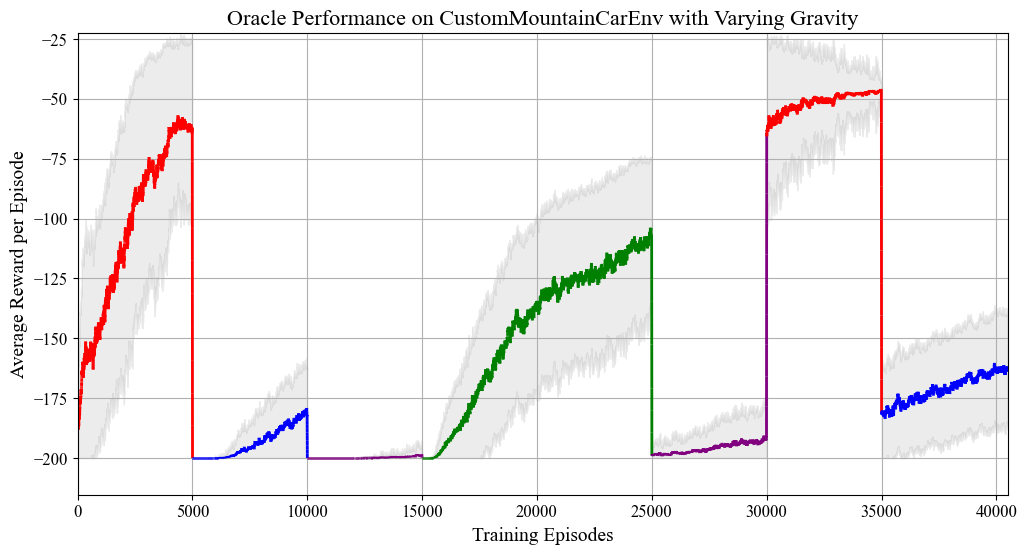

In [15]:
# --- existing smoothing ---
mean_rewards = np.convolve(rewards_F7_oracle[0], np.ones(10)/10, mode='valid')
std_rewards  = np.convolve(rewards_F7_oracle[1], np.ones(10)/10, mode='valid')

# oracle_context must be trimmed to match the smoothed length
ctx = oracle_context[:len(mean_rewards)]

# colour map for contexts
ctx_colors = {
    0: 'red',
    1: 'green',
    2: 'blue',
    3: 'purple'
}

fig, ax = plt.subplots(figsize=(12, 6))

# --- plot confidence band (context-independent) ---
ax.fill_between(
    range(len(mean_rewards)),
    np.clip(mean_rewards - std_rewards, a_min=-200, a_max=None),
    mean_rewards + std_rewards,
    color='grey',
    alpha=0.15
)

# --- plot mean reward with segment colouring using LineCollection ---
x = np.arange(len(mean_rewards))
y = mean_rewards

# Build line segments between successive points
points = np.column_stack((x, y))
segments = np.stack([points[:-1], points[1:]], axis=1)

# One colour per segment, based on context at the start of the segment
segment_colors = [ctx_colors[c] for c in ctx[:-1]]

lc = LineCollection(segments, colors=segment_colors, linewidths=2)
ax.add_collection(lc)

# Ensure axes limits cover the data
ax.set_xlim(x.min(), x.max())
ax.set_ylim((y - std_rewards).min(), (y + std_rewards).max())

# --- formatting ---
ax.set_title('Oracle Performance on CustomMountainCarEnv with Varying Gravity')
ax.set_xlabel('Training Episodes')
ax.set_ylabel('Average Reward per Episode')
ax.grid(True)

plt.show()


## COIN approach

In [16]:
# Set up p_context - from COIN
coin_model = COIN(
    sigma_sensory_noise = 0.003, 
    sigma_motor_noise = 0.00182,
)

# Simplify COIN calculation by assuming parameters stay the same every 500 episodes
coin_model.perturbations = param[::500]

output = coin_model.simulate_coin()

known_c_resp, novel_c_resp = coin_model.get_responsibilities(output)
p_contexts = np.concatenate([known_c_resp,novel_c_resp[:,None]],axis=-1) 
p_contexts = np.repeat(p_contexts, repeats=500, axis=0)

# Ensure COIN probabilities are of the right form
# Novel context - should never have a NaN definition
p_temp = p_contexts.copy()
p_temp[np.isnan(p_temp)] = 0.0
p_contexts[:,-1] = 1 - np.sum(p_temp[:,:-1], axis=1)

# Define coin_context, a variable length (N=len(param)), indicating the active context for each time point (index of p_context that is highest)
coin_context = np.argmax(p_contexts[:,:-1], axis=1)

def run_single_rep_coin_F7(rep_id, g, p_context):
    """
    Runs one repetition of training across all gravitational values in g using COINQLearningAgent with COIN p_contexts.
    Returns the list of rewards.
    """
    # Imports for multiprocessing
    from environments import CustomMountainCarEnv
    from rl import COINQLearningAgent
    # Create a fresh agent and environment inside each process

    C = p_context.shape[1]-1

    env = CustomMountainCarEnv(amplitude=1.0, render_mode="none")
    agent = COINQLearningAgent(
        env=env,
        max_contexts=C,
        num_position_bins=30,
        num_velocity_bins=30,
        alpha=0.1,
        gamma=0.99,
        epsilon=1.0,
        epsilon_decay=0.999
    )

    rewards_for_this_rep = []
    for i, val in enumerate(g):
        # Create the environment for each amplitude
        env = CustomMountainCarEnv(gravity_sf=val, render_mode="none")
        
        # Train the agent in the current context
        training_reward = agent.train_step(env=env, p_context=p_context[i,:], max_steps_per_episode=200)
        rewards_for_this_rep.append(training_reward)

        if (i + 1) % 500 == 0:
            print(f"Repetition {rep_id}, Gravity {val}: Training reward = {training_reward}")

    return rewards_for_this_rep

REWARDS_PATH = "models/fig7_rewards_coin.npy"
if TRAIN:
    # Number of repetitions and number of parallel processes:
    n_reps = N_REPS
    n_processes = MAX_CORES
        
    # Create a Pool of workers
    with mp.Pool(processes=n_processes) as pool:
        # Map each repetition to the function run_single_rep_coin_F7
        all_results = pool.starmap(run_single_rep_coin_F7, [(rep, param, p_contexts) for rep in range(n_reps)])
        
    # all_results is a list of lists: one list of rewards for each repetition
    # Convert to a NumPy array, then average over axis=0 to get mean reward per amplitude
    all_results_array = np.array(all_results)  # shape: (n_reps, len(sf))
    rewards_F7_coin = np.mean(all_results_array, axis=0)
    # Also get error bars (std dev) for plotting
    rewards_F7_coin_std = np.std(all_results_array, axis=0)

    # Concatenate into a single array for saving
    rewards_F7_coin = np.vstack((rewards_F7_coin, rewards_F7_coin_std))

    # Save results
    np.save(REWARDS_PATH, rewards_F7_coin)
    print(f"Training complete. Rewards saved to '{REWARDS_PATH}'.")
else:
    # Load the saved results from the training
    if os.path.exists(REWARDS_PATH):
        rewards_F7_coin = np.load(REWARDS_PATH)
        print(f"Loaded rewards from '{REWARDS_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved rewards found at '{REWARDS_PATH}'.")

Simulating the COIN model
Finding optimal context labels (trial = 50)
Permuting context labels (trial = 50)
Loaded rewards from 'models/fig7_rewards_coin.npy'.


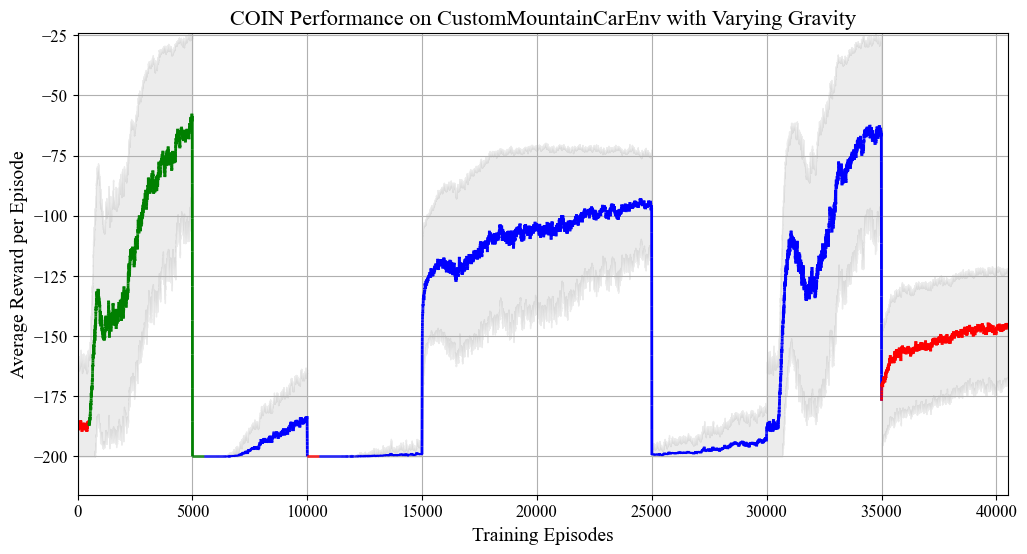

In [19]:
# Plot training results and confidence region
# Extract mean rewards and std dev - smooth for plotting
mean_rewards = np.convolve(rewards_F7_coin[0], np.ones(10)/10, mode='valid')
std_rewards = np.convolve(rewards_F7_coin[1], np.ones(10)/10, mode='valid')

# coin_context must be trimmed to match the smoothed length
ctx = coin_context[:len(mean_rewards)]

# colour map for contexts
ctx_colors = {
    0: 'red',
    1: 'green',
    2: 'blue',
    3: 'purple'
}

fig, ax = plt.subplots(figsize=(12, 6))

# --- plot confidence band (context-independent) ---
ax.fill_between(
    range(len(mean_rewards)),
    np.clip(mean_rewards - std_rewards, a_min=-200, a_max=None),
    mean_rewards + std_rewards,
    color='grey',
    alpha=0.15
)

# --- plot mean reward with segment colouring using LineCollection ---
x = np.arange(len(mean_rewards))
y = mean_rewards

# Build line segments between successive points
points = np.column_stack((x, y))
segments = np.stack([points[:-1], points[1:]], axis=1)

# One colour per segment, based on context at the start of the segment
segment_colors = [ctx_colors[c] for c in ctx[:-1]]

lc = LineCollection(segments, colors=segment_colors, linewidths=2)
ax.add_collection(lc)

# Ensure axes limits cover the data
ax.set_xlim(x.min(), x.max())
ax.set_ylim((y - std_rewards).min(), (y + std_rewards).max())

# --- formatting ---
ax.set_title('COIN Performance on CustomMountainCarEnv with Varying Gravity')
ax.set_xlabel('Training Episodes')
ax.set_ylabel('Average Reward per Episode')
ax.grid(True)

plt.show()


## Embodied COIN Approach

In [47]:
# Train basic Q-learning agent on g=1.0 as our body

# Create the Q-learning agent
env = CustomMountainCarEnv(gravity_sf=1.0, render_mode="none")
body_agent = QLearningAgent(
    env=env,
    num_position_bins=30,
    num_velocity_bins=30,
    alpha=0.1,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.999,
    min_epsilon=0.01
)

rewards_for_this_rep = []
for i in range(10000):    
    # Train the agent in the current context
    training_reward = body_agent.train_step(env=env, max_steps_per_episode=200)
    rewards_for_this_rep.append(training_reward)

    if (i + 1) % 500 == 0:
        print(f"Episode {i}: Training reward = {training_reward}")


Episode 499: Training reward = -200.0
Episode 999: Training reward = -200.0
Episode 1499: Training reward = -200.0
Episode 1999: Training reward = -200.0
Episode 2499: Training reward = -164.0
Episode 2999: Training reward = -200.0
Episode 3499: Training reward = -190.0
Episode 3999: Training reward = -200.0
Episode 4499: Training reward = -198.0
Episode 4999: Training reward = -200.0
Episode 5499: Training reward = -200.0
Episode 5999: Training reward = -200.0
Episode 6499: Training reward = -189.0
Episode 6999: Training reward = -200.0
Episode 7499: Training reward = -200.0
Episode 7999: Training reward = -174.0
Episode 8499: Training reward = -149.0
Episode 8999: Training reward = -148.0
Episode 9499: Training reward = -147.0
Episode 9999: Training reward = -184.0


In [20]:
# Set up p_context - from COIN
coin_model = COIN(
    sigma_sensory_noise = 0.003, 
    sigma_motor_noise = 0.00182,
)

# Simplify COIN calculation by assuming parameters stay the same every 500 episodes
coin_model.perturbations = param[::500]

output = coin_model.simulate_coin()

known_c_resp, novel_c_resp = coin_model.get_responsibilities(output)
p_contexts = np.concatenate([known_c_resp, novel_c_resp[:, None]], axis=-1) 
p_contexts = np.repeat(p_contexts, repeats=500, axis=0)

# Ensure COIN probabilities are of the right form
# Novel context - should never have a NaN definition
p_temp = p_contexts.copy()
p_temp[np.isnan(p_temp)] = 0.0
p_contexts[:, -1] = 1 - np.sum(p_temp[:, :-1], axis=1)

# Define embodied_context, a variable length (N=len(param)), indicating the active context for each time point (index of p_context that is highest)
embodied_context = np.argmax(p_contexts[:, :-1], axis=1)


def run_single_rep_coin_F7(rep_id, g, p_context, body_Q):
    """
    Runs one repetition of training across all gravitational values in g using
    COINQLearningAgent with COIN p_contexts.

    Returns:
        training_rewards: np.ndarray of shape (len(g),)
        eval_rewards:     np.ndarray of shape (len(g),)
    """
    # Imports for multiprocessing
    from environments import CustomMountainCarEnv
    from rl import EmbodiedCOINQLearningAgent
    import numpy as np

    C = p_context.shape[1] - 1

    # Create a base env just for agent initialisation
    env = CustomMountainCarEnv(gravity_sf=1.0, render_mode="none")
    agent = EmbodiedCOINQLearningAgent(
        env=env,
        max_contexts=C,
        num_position_bins=30,
        num_velocity_bins=30,
        alpha=0.1,
        alpha_body=1e-5,
        gamma=0.99,
        epsilon=1.0,
        epsilon_decay=0.999,
        init_Q_random=False
    )

    # Set body Q-learning table
    agent.Qbody = body_Q.copy()

    rewards_for_this_rep = np.zeros((len(g), 2))

    for i, val in enumerate(g):
        # Create the environment for each amplitude
        env = CustomMountainCarEnv(gravity_sf=val, render_mode="none")

        # Train the agent in the current context
        training_reward = agent.train_step(
            env=env,
            p_context=p_context[i, :],
            max_steps_per_episode=200
        )

        # Evaluate the agent in the same context
        eval_reward = agent.evaluate(
            env=env,
            p_context=p_context[i, :],
            max_steps_per_episode=200,
            n_episodes=1
        )

        training_reward = float(np.mean(training_reward))   # or np.mean(...)
        eval_reward     = float(np.mean(eval_reward))

        rewards_for_this_rep[i, :] = [training_reward, eval_reward]

        if (i + 1) % 500 == 0:
            print(
                f"Rep {rep_id}, Gravity {val}: "
                f"Train reward = {training_reward:.3f}, "
                f"Eval reward = {eval_reward:.3f}"
            )

    return rewards_for_this_rep


# Paths for saving
REWARDS_PATH = "models/fig7_rewards_embodied_coin_per_rep.npz"

if TRAIN:
    # Number of repetitions and number of parallel processes:
    n_reps = N_REPS
    n_processes = MAX_CORES

    # Create a Pool of workers
    with mp.Pool(processes=n_processes) as pool:
        # Map each repetition to the function run_single_rep_coin_F7
        all_results = pool.starmap(
            run_single_rep_coin_F7,
            [(rep, param, p_contexts, body_agent.Q.copy()) for rep in range(n_reps)]
        )

    # all_results is a list of arrays of shape (len(g), 2)
    all_results = np.stack(all_results, axis=0)  # (n_reps, len(g), 2)

    # Split train / eval along the last dimension
    all_train = all_results[:, :, 0]  # (n_reps, len(g))
    all_eval  = all_results[:, :, 1]  # (n_reps, len(g))

    # Optionally compute summary stats across repetitions
    rewards_F7_embodied_coin = np.mean(all_train, axis=0)
    rewards_F7_embodied_coin_std  = np.std(all_train, axis=0)
    rewards_F7_embodied_coin_eval_mean  = np.mean(all_eval, axis=0)
    rewards_F7_embodied_coin_eval_std   = np.std(all_eval, axis=0)

    # Save per-process data + summary statistics
    np.savez(
        REWARDS_PATH,
        train_per_rep=all_train,
        eval_per_rep=all_eval,
        train_mean=rewards_F7_embodied_coin,
        train_std=rewards_F7_embodied_coin_std,
        eval_mean=rewards_F7_embodied_coin_eval_mean,
        eval_std=rewards_F7_embodied_coin_eval_std,
    )

    print(f"Training complete. Rewards (train + eval) saved to '{REWARDS_PATH}'.")
else:
    if os.path.exists(REWARDS_PATH):
        data = np.load(REWARDS_PATH)
        all_train = data["train_per_rep"]
        all_eval  = data["eval_per_rep"]
        rewards_F7_embodied_coin = data["train_mean"]
        rewards_F7_embodied_coin_std  = data["train_std"]
        rewards_F7_embodied_coin_eval_mean  = data["eval_mean"]
        rewards_F7_embodied_coin_eval_std   = data["eval_std"]
        print(f"Loaded rewards (train + eval) from '{REWARDS_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved rewards found at '{REWARDS_PATH}'.")


Simulating the COIN model
Finding optimal context labels (trial = 50)
Permuting context labels (trial = 50)
Loaded rewards (train + eval) from 'models/fig7_rewards_embodied_coin_per_rep.npz'.


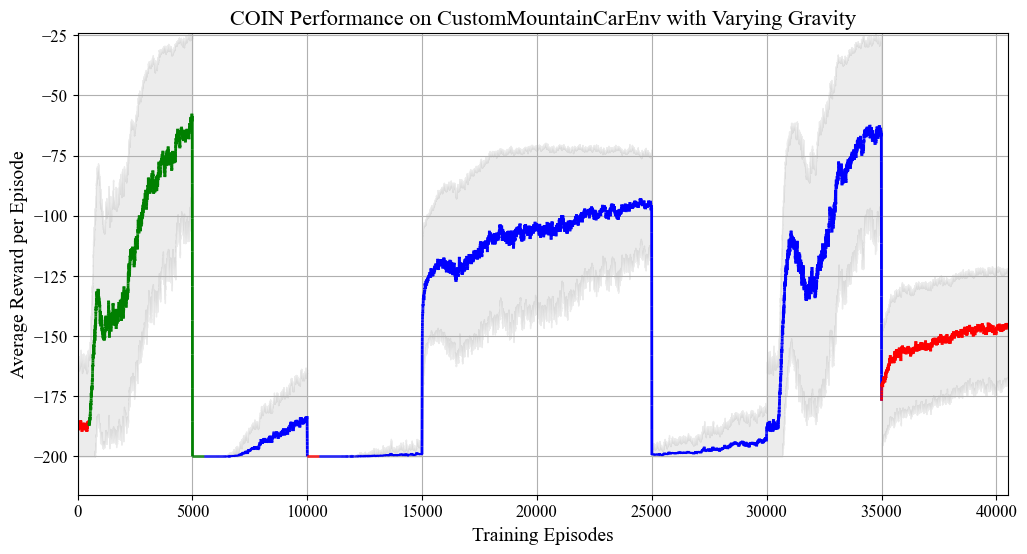

In [21]:
# Plot training results and confidence region
# Extract mean rewards and std dev - smooth for plotting
mean_rewards = np.convolve(rewards_F7_embodied_coin, np.ones(10)/10, mode='valid')
std_rewards = np.convolve(rewards_F7_embodied_coin_std, np.ones(10)/10, mode='valid')
# Plot training results and confidence region
# Extract mean rewards and std dev - smooth for plotting
mean_rewards = np.convolve(rewards_F7_coin[0], np.ones(10)/10, mode='valid')
std_rewards = np.convolve(rewards_F7_coin[1], np.ones(10)/10, mode='valid')

# coin_context must be trimmed to match the smoothed length
ctx = coin_context[:len(mean_rewards)]

# colour map for contexts
ctx_colors = {
    0: 'red',
    1: 'green',
    2: 'blue',
    3: 'purple'
}

fig, ax = plt.subplots(figsize=(12, 6))

# --- plot confidence band (context-independent) ---
ax.fill_between(
    range(len(mean_rewards)),
    np.clip(mean_rewards - std_rewards, a_min=-200, a_max=None),
    mean_rewards + std_rewards,
    color='grey',
    alpha=0.15
)

# --- plot mean reward with segment colouring using LineCollection ---
x = np.arange(len(mean_rewards))
y = mean_rewards

# Build line segments between successive points
points = np.column_stack((x, y))
segments = np.stack([points[:-1], points[1:]], axis=1)

# One colour per segment, based on context at the start of the segment
segment_colors = [ctx_colors[c] for c in ctx[:-1]]

lc = LineCollection(segments, colors=segment_colors, linewidths=2)
ax.add_collection(lc)

# Ensure axes limits cover the data
ax.set_xlim(x.min(), x.max())
ax.set_ylim((y - std_rewards).min(), (y + std_rewards).max())

# --- formatting ---
ax.set_title('COIN Performance on CustomMountainCarEnv with Varying Gravity')
ax.set_xlabel('Training Episodes')
ax.set_ylabel('Average Reward per Episode')
ax.grid(True)

plt.show()


In [50]:
# Also evaluate the body agent (without training) for the parameter values
def run_single_rep_body(rep_id, g, body_Q):
    """
    Runs one repetition of training across all gravitational values in g using COINQLearningAgent with COIN p_contexts.
    Returns the list of rewards.
    """
    # Imports for multiprocessing
    from environments import CustomMountainCarEnv
    from rl import QLearningAgent
    # Create a fresh agent and environment inside each process

    env = CustomMountainCarEnv(gravity_sf=1.0, render_mode="none")
    agent = QLearningAgent(
        env=env,
        num_position_bins=30,
        num_velocity_bins=30,
        alpha=0.1,
        gamma=0.99,
        epsilon=1.0,
        epsilon_decay=0.999,
        min_epsilon=0.01
    )

    # Set body Q-learning table
    agent.Q = body_Q.copy()

    rewards_for_this_rep = []
    for i, val in enumerate(g):
        # Create the environment for each amplitude
        env = CustomMountainCarEnv(gravity_sf=val, render_mode="none")
        
        # Train the agent in the current context
        training_reward = agent.evaluate(env=env, n_episodes=1, max_steps_per_episode=200)
        rewards_for_this_rep.append(training_reward[0])

        if (i + 1) % 500 == 0:
            print(f"Repetition {rep_id}, Gravity {val}: Training reward = {training_reward}")

    return rewards_for_this_rep

REWARDS_PATH = "models/fig7_rewards_body.npy"
if TRAIN:
    # Number of repetitions and number of parallel processes:
    n_reps = N_REPS
    n_processes = MAX_CORES
        
    # Create a Pool of workers
    with mp.Pool(processes=n_processes) as pool:
        # Map each repetition to the function run_single_rep_body
        all_results = pool.starmap(run_single_rep_body, [(rep, param, body_agent.Q.copy()) for rep in range(n_reps)])
        
    # all_results is a list of lists: one list of rewards for each repetition
    # Convert to a NumPy array, then average over axis=0 to get mean reward per amplitude
    all_results_array = np.array(all_results)  # shape: (n_reps, len(sf))
    rewards_F7_body = np.mean(all_results_array, axis=0)
    # Also get error bars (std dev) for plotting
    rewards_F7_body_std = np.std(all_results_array, axis=0)

    # Concatenate into a single array for saving
    rewards_F7_body = np.vstack((rewards_F7_body, rewards_F7_body_std))

    # Save results
    np.save(REWARDS_PATH, rewards_F7_body)
    print(f"Training complete. Rewards saved to '{REWARDS_PATH}'.")
else:
    # Load the saved results from the training
    if os.path.exists(REWARDS_PATH):
        rewards_F7_body = np.load(REWARDS_PATH)
        print(f"Loaded rewards from '{REWARDS_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved rewards found at '{REWARDS_PATH}'.")

Training complete. Rewards saved to 'models/fig7_rewards_body.npy'.


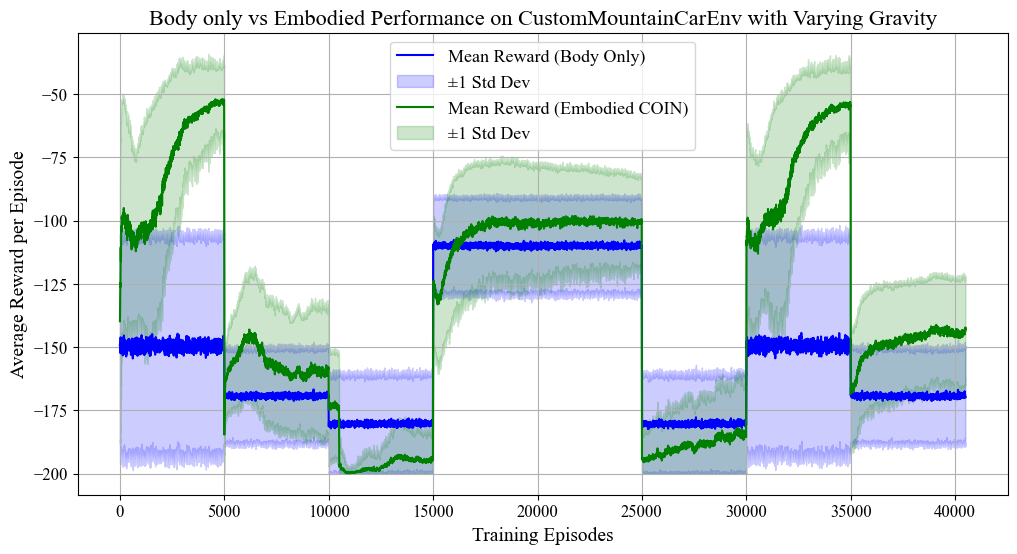

In [51]:
# Plot evaluation results and confidence region
# Create figure and axis
fig, ax = plt.subplots(figsize=(12, 6))
# Extract mean rewards and std dev - smooth for plotting
mean_rewards_body = np.convolve(rewards_F7_body[0], np.ones(10)/10, mode='valid')
std_rewards_body = np.convolve(rewards_F7_body[1], np.ones(10)/10, mode='valid')
# Plot mean rewards
ax.plot(mean_rewards_body, label='Mean Reward (Body Only)', color='blue')
# Plot confidence region
ax.fill_between(
    range(len(mean_rewards)),
    np.clip(mean_rewards_body - std_rewards_body, a_min=-200, a_max=None),
    mean_rewards_body + std_rewards_body,
    color='blue',
    alpha=0.2,
    label='±1 Std Dev'
) 
# Extract mean rewards and std dev for embodied approach - smooth for plotting
mean_rewards_embodied = np.convolve(rewards_F7_embodied_coin_eval_mean, np.ones(10)/10, mode='valid')
std_rewards_embodied = np.convolve(rewards_F7_embodied_coin_eval_std, np.ones(10)/10, mode='valid')
# Plot mean rewards
ax.plot(mean_rewards_embodied, label='Mean Reward (Embodied COIN)', color='green')
# Plot confidence region
ax.fill_between(
    range(len(mean_rewards_embodied)),
    np.clip(mean_rewards_embodied - std_rewards_embodied, a_min=-200, a_max=None),
    mean_rewards_embodied + std_rewards_embodied,
    color='green',
    alpha=0.2,
    label='±1 Std Dev'
) 
ax.set_title('Body only vs Embodied Performance on CustomMountainCarEnv with Varying Gravity')
ax.set_xlabel('Training Episodes')
ax.set_ylabel('Average Reward per Episode')
ax.legend()
ax.grid(True)
plt.show()

## Optimal Values
To find normalised return for each context.

In [ ]:
if TRAIN:
    # Optimal model will train on the amplitude values for 30000 episodes
    envs = [CustomMountainCarEnv(gravity_sf=gsf, render_mode="none") for gsf in [0.0, 0.5, 1.0, 1.5]]
    agents = [QLearningAgent(
        env=envs[i],
        num_position_bins=30,
        num_velocity_bins=30,
        alpha=0.1,
        gamma=0.99,
        epsilon=1.0,
        epsilon_decay=0.9999,
        min_epsilon=0.01
    ) for i in range(4)]

    rewards_optimal = []

    for i in range(4):
        # Create the MountainCar environment with the true amplitude
        env = envs[i]

        # Train the agent in the current context
        agent = agents[i]
        _, training_rewards = agent.train(
            env=env,
            max_steps_per_episode=200,
            n_episodes=30000,
        )

        rewards_optimal.append(np.max(training_rewards))

        # Print the average training reward every 500 episodes
        print(f"Agent {i+1}, Average Training reward: {np.mean(training_rewards[-1000:])}")

    for i in range(4):
        # Create the MountainCar environment with the true gravity scale factors
        env = envs[i]

        # Evaluate the agent in the current context
        agent = agents[i]
        evaluation_reward = agent.evaluate(
            env=env,
            max_steps_per_episode=200,
            n_episodes=1,
        )

        # If evaluation_reward[0] > rewards_optimal[i], substitute:
        if evaluation_reward[0] > rewards_optimal[i]:
            rewards_optimal[i] = evaluation_reward[0]

        # Save results
        np.save("models/fig7_rewards_optimal.npy", rewards_optimal)
        with open("models/fig7_rewards_optimal.pkl", "wb") as f:
            pickle.dump(agents, f)
else:
    # Load the saved results from the training
    if os.path.exists("models/fig7_rewards_optimal.npy"):
        rewards_optimal = np.load("models/fig7_rewards_optimal.npy")
        print(f"Loaded rewards from 'models/fig7_rewards_optimal.npy'.")
    else:
        raise FileNotFoundError(f"No saved rewards found at 'models/fig7_rewards_optimal.npy'.")
    if os.path.exists("models/fig7_rewards_optimal.pkl"):
        with open("models/fig7_rewards_optimal.pkl", "rb") as f:
            agents = pickle.load(f)
        print(f"Loaded agents from 'models/fig7_rewards_optimal.pkl'.")
    else:
        raise FileNotFoundError(f"No saved agents found at 'models/fig7_rewards_optimal.pkl'.")

Agent 1, Average Training reward: -47.897
Agent 2, Average Training reward: -104.086
Agent 3, Average Training reward: -151.688
Agent 4, Average Training reward: -188.04


## Final Plot

In [74]:
def bin_curve(y, bin_size=200):
    """
    Average y over non-overlapping bins of length bin_size.
    Returns x (bin centers) and y_binned.
    """
    n_bins = len(y) // bin_size
    if n_bins == 0:
        return np.arange(len(y)), y
    y = y[:n_bins * bin_size].reshape(n_bins, bin_size).mean(axis=1)
    x = (np.arange(n_bins) * bin_size) + bin_size / 2.0
    return x, y

def expected_context(p_ctx):
    """
    p_ctx: (N, C) context probabilities.
    Returns: (N,) expected context index in [0, C-1].
    """
    N, C = p_ctx.shape
    idx = np.arange(C)
    # Set nan values to zero
    p_ctx = np.nan_to_num(p_ctx, nan=0.0)
    return (p_ctx * idx[None, :]).sum(axis=1)

In [76]:
mean_zeroshot_raw  = rewards_F7_zeroshot[0].copy()
mean_oracle_raw    = rewards_F7_oracle[0].copy()
mean_coin_raw      = rewards_F7_coin[0].copy()
mean_embodied_raw  = rewards_F7_embodied_coin.copy()

# Find normalised performance from means
max_reward = np.zeros_like(param)
for i, g_val in enumerate([0.0, 0.5, 1.0, 1.5]):
    indices = np.where(param == g_val)[0]
    max_reward[indices] = rewards_optimal[i]
mean_zeroshot_raw = (mean_zeroshot_raw + 200) / (max_reward + 200)
mean_oracle_raw   = (mean_oracle_raw + 200) / (max_reward + 200)
mean_coin_raw     = (mean_coin_raw + 200) / (max_reward + 200)
mean_embodied_raw = (mean_embodied_raw + 200) / (max_reward + 200)

ctx_zeroshot_full  = np.zeros_like(mean_zeroshot_raw, dtype=int)
ctx_oracle_full    = oracle_context
ctx_coin_full      = coin_context
ctx_embodied_full  = embodied_context

p_ctx_coin      = p_contexts.copy()
p_ctx_embodied  = p_contexts.copy()

param_full      = param.copy()

ctx_colors = {0: 'red', 1: 'green', 2: 'blue', 3: 'purple'}

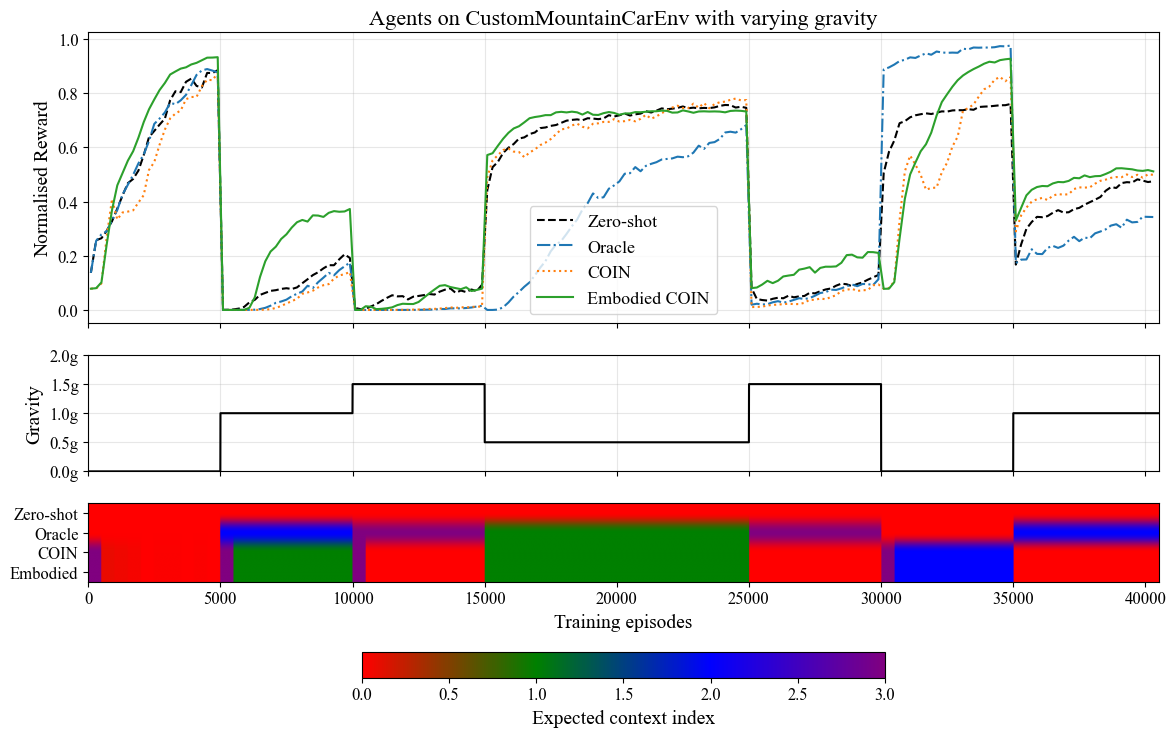

In [ ]:
# -------------------------
# Align lengths (safeguard)
# -------------------------
N = min(
    len(mean_zeroshot_raw),
    len(mean_oracle_raw),
    len(mean_coin_raw),
    len(mean_embodied_raw),
    len(ctx_zeroshot_full),
    len(ctx_oracle_full),
    param_full.shape[0],
    p_ctx_coin.shape[0],
    p_ctx_embodied.shape[0],
)

mean_zeroshot_raw  = mean_zeroshot_raw[:N]
mean_oracle_raw    = mean_oracle_raw[:N]
mean_coin_raw      = mean_coin_raw[:N]
mean_embodied_raw  = mean_embodied_raw[:N]

ctx_zeroshot_full  = ctx_zeroshot_full[:N]
ctx_oracle_full    = ctx_oracle_full[:N]
param_full         = param_full[:N]
p_ctx_coin         = p_ctx_coin[:N, :]
p_ctx_embodied     = p_ctx_embodied[:N, :]

# -------------------------
# Binned reward curves (top panel)
# -------------------------
bin_size = 200  # tune for smoothness

x_z, y_z = bin_curve(mean_zeroshot_raw,  bin_size)
x_o, y_o = bin_curve(mean_oracle_raw,    bin_size)
x_c, y_c = bin_curve(mean_coin_raw,      bin_size)
x_e, y_e = bin_curve(mean_embodied_raw,  bin_size)

# -------------------------
# Expected contexts for heatmap (bottom panel)
# -------------------------
exp_ctx_zeroshot = ctx_zeroshot_full.astype(float)
exp_ctx_oracle   = ctx_oracle_full.astype(float)
exp_ctx_coin     = expected_context(p_ctx_coin)
exp_ctx_embodied = expected_context(p_ctx_embodied)

# Stack: each row = method
E_ctx = np.vstack([
    exp_ctx_zeroshot,
    exp_ctx_oracle,
    exp_ctx_coin,
    exp_ctx_embodied
])  # shape (4, N)

# number of contexts from probability arrays
C = p_ctx_coin.shape[1]

# Base colours you want for discrete contexts 0..C-1
ctx_colors = {
    0: 'red',
    1: 'green',
    2: 'blue',
    3: 'purple'
}
base_colors = [ctx_colors[i] for i in range(C)]
cmap_ctx = LinearSegmentedColormap.from_list("ctx_prob", base_colors, N=256)

# -------------------------
# Figure with 3 stacked panels
# -------------------------
fig = plt.figure(figsize=(12, 8))
gs = GridSpec(3, 1, height_ratios=[3, 1.2, 1.8])

ax_main  = fig.add_subplot(gs[0])
ax_param = fig.add_subplot(gs[1], sharex=ax_main)
ax_ctx   = fig.add_subplot(gs[2], sharex=ax_main)

# ---- Top: reward vs episodes (binned) ----
ax_main.plot(x_z, y_z, '--', color='black',      label='Zero-shot')
ax_main.plot(x_o, y_o, '-.', color='tab:blue',   label='Oracle')
ax_main.plot(x_c, y_c, ':',  color='tab:orange', label='COIN')
ax_main.plot(x_e, y_e, '-',  color='tab:green',  label='Embodied COIN')

ax_main.set_ylabel('Normalised Performance')
ax_main.set_title('Agents on CustomMountainCarEnv with varying gravity')
ax_main.grid(True, alpha=0.3)
ax_main.legend()

ax_main.set_xlim(0, N)

# Hide x tick labels for top axes
plt.setp(ax_main.get_xticklabels(), visible=False)

# ---- Middle: true parameter vs episodes ----
ax_param.plot(np.arange(N), param_full, '-', color='k')
ax_param.set_ylabel(r'Gravity')
ax_param.grid(True, alpha=0.3)
ax_param.set_ylim(0.0, 2.0)
# Set parameter ticks to multiples of g
ax_param.set_yticks([0.0, 0.5, 1.0, 1.5, 2.0])
ax_param.set_yticklabels(['0.0g', '0.5g', '1.0g', '1.5g', '2.0g'])

plt.setp(ax_param.get_xticklabels(), visible=False)

# ---- Bottom: context expectation heatmap ----
im = ax_ctx.imshow(
    E_ctx,
    aspect='auto',
    cmap=cmap_ctx,
    vmin=0,
    vmax=C - 1,
    origin='upper'
)

ax_ctx.set_yticks(range(4))
ax_ctx.set_yticklabels(['Zero-shot', 'Oracle', 'COIN', 'Embodied'])

ax_ctx.set_xlabel('Training episodes')
ax_ctx.set_xlim(0, N - 1)

cbar = fig.colorbar(
    im, ax=ax_ctx,
    orientation='horizontal',
    pad=0.4,
    location='bottom'
)
cbar.set_label('Expected context index')

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# Figure 8: Trained results, Evaluation
## Training - Mountain Car
We train, for now, a *single* agent for each of our models on the provided data.
**Important**:
* Extend this to *SOTA models*.
* Repeat these for *multiple agents* and take averages.

**Training Info**
* All of these models are trained on the same sequence of data and epochs.
* We only perform this for the *MountainCar* environment varying *gravity* at this stage.

### Parameter Definition

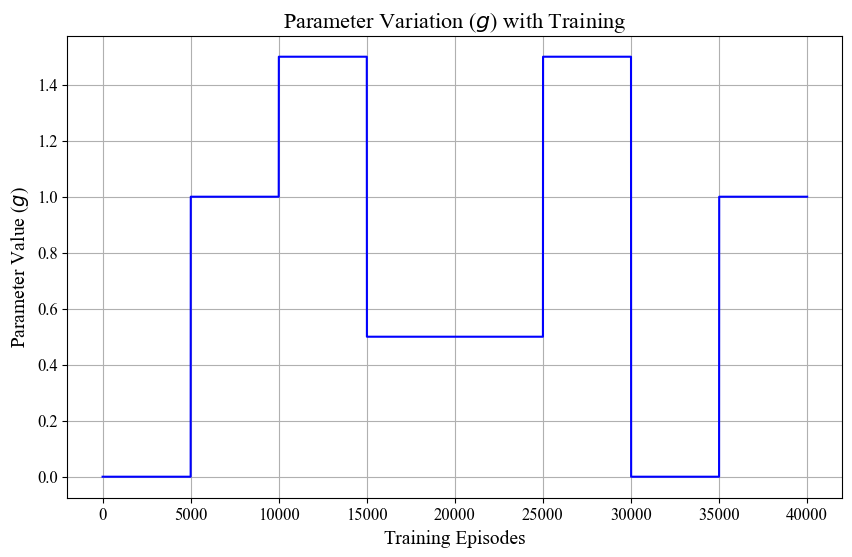

In [5]:
# Parameter values
param = np.concatenate([
    0.0*np.ones((5000, )), 
    1.0*np.ones((5000, )),
    1.5*np.ones((5000, )),
    0.5*np.ones((5000, )),
    0.5*np.ones((5000, )),
    1.5*np.ones((5000, )),
    0.0*np.ones((5000, )),
    1.0*np.ones((5000, )),
    ])

TRAIN = False # Set to True to train, False to load saved results

# Plot parameter variation
# Font setup
plt.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "legend.fontsize": 13,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# Create figure and axiss
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(param, color='blue')
ax.set_title(r'Parameter Variation ($g$) with Training')
ax.set_xlabel('Training Episodes')
ax.set_ylabel(r'Parameter Value ($g$)')
ax.grid(True)
plt.show()


### Zero-shot Training

In [6]:
# Train zero-shot agent
env = CustomMountainCarEnv(gravity_sf=1.0, render_mode="none")
zero_shot_agent = QLearningAgent(
    env=env,
    num_position_bins=30,
    num_velocity_bins=30,
    alpha=0.1,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.999
)

# Just train directly
AGENT_PATH = "models/fig8_agent_zeroshot.pkl"
if TRAIN:
    for i, gsf in enumerate(param):
        # Create the environment for each amplitude
        env = CustomMountainCarEnv(gravity_sf=gsf, render_mode="none")
        
        # Train the agent in the current context
        training_reward = zero_shot_agent.train_step(env=env, max_steps_per_episode=200)

        if (i + 1) % 500 == 0:
            print(f"Episode {i+1}, Gravity {gsf}: Training reward = {training_reward}")
    # Save agent object with pickle
    with open(AGENT_PATH, "wb") as f:
        pickle.dump(zero_shot_agent, f)
else:
    # Load agent object
    if os.path.exists(AGENT_PATH):
        with open(AGENT_PATH, "rb") as f:
            zero_shot_agent = pickle.load(f)
        print(f"Loaded zero-shot agent from '{AGENT_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved agent found at '{AGENT_PATH}'.")

Loaded zero-shot agent from 'models/fig8_agent_zeroshot.pkl'.


In [7]:
# Evaluate ecdf across all parameter values

# Unique gravity scale factors
unique_gsf = np.unique(param)

# Create dictionary to hold ecdf results
ecdf_results_zeroshot = {}

for gsf in unique_gsf:
    # Create the environment for each amplitude
    env = CustomMountainCarEnv(gravity_sf=gsf, render_mode="none")
    
    # Evaluate the agent in the current context, for 1000 episodes
    evaluation_reward = zero_shot_agent.evaluate(env=env, n_episodes=1000, max_steps_per_episode=200)

    # Find ecdf of evaluation rewards
    sorted_rewards = np.sort(evaluation_reward)
    ecdf = np.arange(1, len(sorted_rewards) + 1) / len(sorted_rewards)

    # Store in dictionary
    ecdf_results_zeroshot[gsf] = (sorted_rewards, ecdf)

### Oracle Training

In [8]:
# Train oracle agent on g values with oracle p_contexts
p_contexts_oracle = np.zeros((len(param), 5))
for i, gsf in enumerate(param):
    if gsf == 0.0:
        p_contexts_oracle[i, 0] = 1.0
    elif gsf == 0.5:
        p_contexts_oracle[i, 1] = 1.0
    elif gsf == 1.0:
        p_contexts_oracle[i, 2] = 1.0
    elif gsf == 1.5:
        p_contexts_oracle[i, 3] = 1.0

# Train oracle agent once
env = CustomMountainCarEnv(gravity_sf=1.0, render_mode="none")
oracle_agent = COINQLearningAgent(
    env=env,
    max_contexts=4,
    num_position_bins=30,
    num_velocity_bins=30,
    alpha=0.1,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.999
)

AGENT_PATH = "models/fig8_agent_oracle.pkl"
if TRAIN:
    for i, gsf in enumerate(param):
        # Create the environment for each amplitude
        env = CustomMountainCarEnv(gravity_sf=gsf, render_mode="none")
        
        # Train the agent in the current context
        training_reward = oracle_agent.train_step(env=env, p_context=p_contexts_oracle[i,:], max_steps_per_episode=200)

        if (i + 1) % 500 == 0:
            print(f"Episode {i+1}, Gravity {gsf}: Training reward = {training_reward}")
    # Save agent object with pickle
    with open(AGENT_PATH, "wb") as f:
        pickle.dump(oracle_agent, f)
else:
    # Load agent object
    if os.path.exists(AGENT_PATH):
        with open(AGENT_PATH, "rb") as f:
            oracle_agent = pickle.load(f)
        print(f"Loaded oracle agent from '{AGENT_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved agent found at '{AGENT_PATH}'.")

Loaded oracle agent from 'models/fig8_agent_oracle.pkl'.


In [9]:
# Evaluate ecdf across all parameter values

# Unique gravity scale factors
unique_gsf = np.unique(param)

# Create dictionary to hold ecdf results
ecdf_results_oracle = {}

for gsf in unique_gsf:
    # Create the environment for each amplitude
    env = CustomMountainCarEnv(gravity_sf=gsf, render_mode="none")
    
    # Evaluate the agent in the current context, for 1000 episodes
    p_context = np.zeros((5, ))
    if gsf == 0.0:
        p_context[0] = 1.0
    elif gsf == 0.5:
        p_context[1] = 1.0
    elif gsf == 1.0:
        p_context[2] = 1.0
    elif gsf == 1.5:
        p_context[3] = 1.0
    
    evaluation_reward = oracle_agent.evaluate(env=env, p_context=p_context, n_episodes=1000, max_steps_per_episode=200)

    # Find ecdf of evaluation rewards
    sorted_rewards = np.sort(evaluation_reward)
    ecdf = np.arange(1, len(sorted_rewards) + 1) / len(sorted_rewards)

    # Store in dictionary
    ecdf_results_oracle[gsf] = (sorted_rewards, ecdf)

### COIN Training

In [ ]:
# Train coin agent on g values
# Set up p_context - from COIN
coin_model = COIN(
    sigma_sensory_noise = 0.003, 
    sigma_motor_noise = 0.00182,
)

# Simplify COIN calculation by assuming parameters stay the same every 500 episodes
coin_model.perturbations = param[::500]

output = coin_model.simulate_coin()

known_c_resp, novel_c_resp = coin_model.get_responsibilities(output)
p_contexts = np.concatenate([known_c_resp,novel_c_resp[:,None]],axis=-1) 
p_contexts = np.repeat(p_contexts, repeats=500, axis=0)

# Ensure COIN probabilities are of the right form
# Novel context - should never have a NaN definition
p_temp = p_contexts.copy()
p_temp[np.isnan(p_temp)] = 0.0
p_contexts[:,-1] = 1 - np.sum(p_temp[:,:-1], axis=1)

C = p_contexts.shape[1]-1

# Train oracle agent once
env = CustomMountainCarEnv(gravity_sf=1.0, render_mode="none")
coin_agent = COINQLearningAgent(
    env=env,
    max_contexts=C,
    num_position_bins=30,
    num_velocity_bins=30,
    alpha=0.1,
    gamma=0.99,
    epsilon=1.0,
    epsilon_decay=0.999
)

AGENT_PATH = "models/fig8_agent_coin.pkl"
if TRAIN:
    for i, gsf in enumerate(param):
        # Create the environment for each amplitude
        env = CustomMountainCarEnv(gravity_sf=gsf, render_mode="none")
        
        # Train the agent in the current context
        training_reward = coin_agent.train_step(env=env, p_context=p_contexts_coin[i,:], max_steps_per_episode=200)

        if (i + 1) % 500 == 0:
            print(f"Episode {i+1}, Gravity {gsf}: Training reward = {training_reward}")
    # Save agent object with pickle
    with open(AGENT_PATH, "wb") as f:
        pickle.dump(coin_agent, f)
else:
    # Load agent object
    if os.path.exists(AGENT_PATH):
        with open(AGENT_PATH, "rb") as f:
            coin_agent = pickle.load(f)
        print(f"Loaded coin agent from '{AGENT_PATH}'.")
    else:
        raise FileNotFoundError(f"No saved agent found at '{AGENT_PATH}'.")

Simulating the COIN model


LinAlgError: Last 2 dimensions of the array must be square

In [ ]:
stat_prob = coin_model.get_stationary_probabilities(output)

Finding optimal context labels (trial = 50)


KeyError: 'stationary_probabilities'

In [ ]:
# Evaluate ecdf across all parameter values

# Unique gravity scale factors
unique_gsf = np.unique(param)

# Create dictionary to hold ecdf results
ecdf_results_coin = {}

for gsf in unique_gsf:
    # Create the environment for each amplitude
    env = CustomMountainCarEnv(gravity_sf=gsf, render_mode="none")
    
    # Evaluate the agent in the current context, for 1000 episodes
    # TODO: set p_context correctly
    # It needs to be obtained from the stationary probabilities of the COIN model
    p_context = np.zeros((5, ))
    if gsf == 0.0:
        p_context[0] = 1.0
    elif gsf == 0.5:
        p_context[1] = 1.0
    elif gsf == 1.0:
        p_context[2] = 1.0
    elif gsf == 1.5:
        p_context[3] = 1.0
    
    evaluation_reward = coin_agent.evaluate(env=env, p_context=p_context, n_episodes=1000, max_steps_per_episode=200)

    # Find ecdf of evaluation rewards
    sorted_rewards = np.sort(evaluation_reward)
    ecdf = np.arange(1, len(sorted_rewards) + 1) / len(sorted_rewards)

    # Store in dictionary
    ecdf_results_coin[gsf] = (sorted_rewards, ecdf)

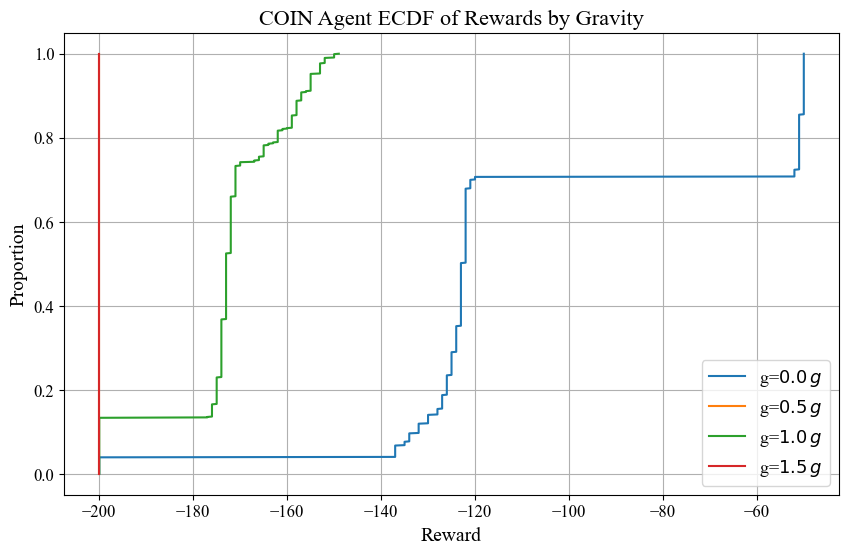

In [ ]:
# Plot ecdfs
fig, ax = plt.subplots(figsize=(10, 6))
for gsf in unique_gsf:
    sorted_rewards, ecdf = ecdf_results_coin[gsf]
    ax.plot(sorted_rewards, ecdf, label=rf'g=${gsf}\,g$')

ax.set_title('COIN Agent ECDF of Rewards by Gravity')
ax.set_xlabel('Reward')
ax.set_ylabel('Proportion')
ax.grid(True)
ax.legend()
plt.show()

# Figure 9: Generalisation to Unseen Contexts